<a href="https://colab.research.google.com/github/HERO-DS/git-practice/blob/main/Data_Cleaning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import numpy as np

In [31]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shuofxz/titanic-machine-learning-from-disaster")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-machine-learning-from-disaster' dataset.
Path to dataset files: /kaggle/input/titanic-machine-learning-from-disaster


In [32]:
df_raw_train = pd.read_csv("/kaggle/input/titanic-machine-learning-from-disaster/train.csv")
print(df_raw_train.shape)
df_raw_test = pd.read_csv("/kaggle/input/titanic-machine-learning-from-disaster/test.csv")
print(df_raw_test.shape)
titanic_df = pd.concat([df_raw_train, df_raw_test], ignore_index=True)

print("Complete dataset is :", titanic_df.shape)

(891, 12)
(418, 11)
Complete dataset is : (1309, 12)


In [33]:
titanic_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [34]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [35]:
titanic_df.duplicated().sum()
#print(titanic_df[titanic_df.duplicated()])

np.int64(0)

In [36]:
cat_col = [col for col in titanic_df.columns if titanic_df[col].dtype == 'object']
print("Categorical", cat_col)
num_col = [col for col in titanic_df.columns if titanic_df[col].dtype != 'object']
print("Numerical", num_col)

Categorical ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [37]:
titanic_df.nunique()

,0
PassengerId,1309
Survived,2
Pclass,3
Name,1307
Sex,2
Age,98
SibSp,7
Parch,8
Ticket,929
Fare,281


In [38]:
round((titanic_df.isnull().sum() / titanic_df.shape[0]) * 100, 2)

,0
PassengerId,0.00
Survived,31.93
Pclass,0.00
Name,0.00
Sex,0.00
Age,20.09
SibSp,0.00
Parch,0.00
Ticket,0.00
Fare,0.08


In [39]:
df1 = titanic_df.drop(columns=['Name', 'Ticket', 'Cabin'])
df1.dropna(subset=['Embarked'], inplace=True)
df1['Age'] = df1['Age'].fillna(df1['Age'].mean())

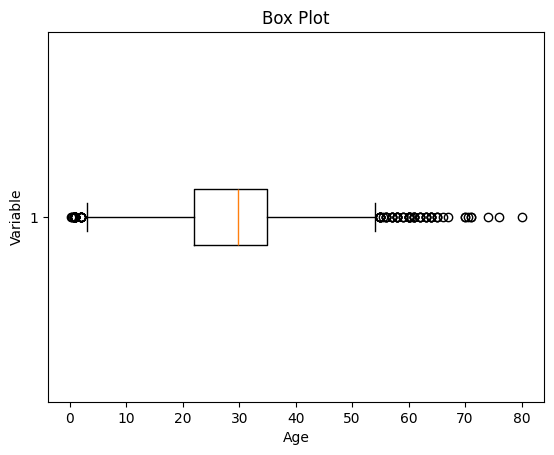

In [40]:
import matplotlib.pyplot as plt
plt.boxplot(df1['Age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()

In [41]:
mean = df1['Age'].mean()
std = df1['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

df2 = df1[(df1['Age'] >= lower_bound) & (df1['Age'] <= upper_bound)]

In [42]:
round((df2.isnull().sum() / df2.shape[0]) * 100, 2)

,0
PassengerId,0.00
Survived,32.36
Pclass,0.00
Sex,0.00
Age,0.00
SibSp,0.00
Parch,0.00
Fare,0.00
Embarked,0.00


In [43]:
df3 = df2.fillna(df2['Age'].mean())
df3.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [44]:
mean = df3['Age'].mean()
std = df3['Age'].std()

lower_bound2 = mean - 2 * std
upper_bound2 = mean + 2 * std

print(lower_bound2, upper_bound2)

clean_df = df3[(df3['Age'] >= lower_bound2) & (df3['Age'] <= upper_bound2)]


9.907610422874846 49.06003376656782


In [45]:
X = clean_df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
Y = clean_df['Survived']

In [47]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
x1 = X.copy()

num_col =[col for col in X.columns if X[col].dtype !='object']
x1[num_col] = scaler.fit_transform(x1[num_col])

x1.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,male,0.307692,0.125,0.0,0.014151,S
1,0.0,female,0.717949,0.125,0.0,0.139136,C
2,1.0,female,0.410256,0.000,0.0,0.015469,S
3,0.0,female,0.641026,0.125,0.0,0.103644,S
4,1.0,male,0.641026,0.000,0.0,0.015713,S
